- Name: Farrel Augusta Dinata
- Class: TI-3H
- NIM: 2341720081
- Roll number: 12

# Preparation

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Practicum

## 1. Image Dilation from Scratch

In [3]:
def image_dilation(
    F: np.ndarray, 
    w: int
) -> np.ndarray:
    """
    Perform image dilation on a grayscale image using a square structuring element.

    Parameters
    ----------
    F : np.ndarray
        Input grayscale image as a 2D NumPy array.
    w : int
        Size of the square structuring element (must be odd).

    Returns
    -------
    np.ndarray
        Dilated image as a 2D NumPy array with the same shape as the input.
    """
    p, q = F.shape
    img_d = np.zeros((p, q), dtype=np.uint8)

    # Generate structuring element (square matrix of ones)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2

    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[
                i - constant1:i + constant1 + 1,
                j - constant1:j + constant1 + 1
            ]
            product = temp * SED
            img_d[i, j] = np.max(product)

    return img_d

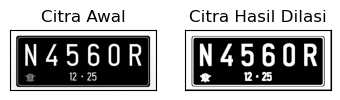

In [5]:
img = cv2.imread('../assets/plat-nomor.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img, 
    thresh=125, 
    maxval=200, 
    type=cv2.THRESH_BINARY
)

img_d = image_dilation(thresh, w=5)

plt.subplot(131)
plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(img_d,cmap = 'gray')
plt.title('Citra Hasil Dilasi')
plt.xticks([])
plt.yticks([])
plt.show()

## 2. Image Dilation with OpenCV

Kernel: 
 [[1 1 1]
 [1 1 1]
 [1 1 1]]


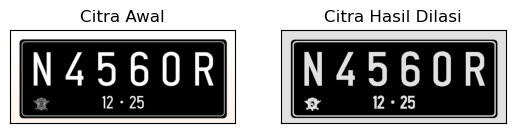

In [9]:
img = cv2.imread('../assets/plat-nomor.jpg')

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img, 
    thresh=127, 
    maxval=225, 
    type=cv2.THRESH_BINARY
)
kernel = np.ones((3,3),np.uint16)
dilasi = cv2.dilate(thresh,kernel, iterations = 1)
print('Kernel: \n', kernel)

plt.subplot(121)
plt.imshow(img)
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(dilasi)
plt.title('Citra Hasil Dilasi')
plt.xticks([])
plt.yticks([])
plt.show()

## 3. Image Erotion from Scratch

In [10]:
def image_erosion(
    F: np.ndarray, 
    k: int
) -> np.ndarray:
    """
    Perform image erosion on a grayscale or binary image using a square structuring element.

    Parameters
    ----------
    F : np.ndarray
        Input image as a 2D NumPy array (uint8).
    k : int
        Size of the square structuring element (must be odd).

    Returns
    -------
    np.ndarray
        Eroded image as a 2D NumPy array.
    """
    m, n = F.shape

    # Generate structuring element (square matrix of ones)
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2

    # Initialize output image
    img_e = np.zeros((m, n), dtype=np.uint8)

    # Erosion process
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[
                i - constant:i + constant + 1,
                j - constant:j + constant + 1
            ]
            product = temp * SE
            img_e[i, j] = np.min(product)

    return img_e

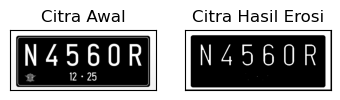

In [11]:
img = cv2.imread('../assets/plat-nomor.jpg', flags=cv2.IMREAD_GRAYSCALE) 

if img is None:
    raise Exception('Image is not found!')


ret1, thresh1 = cv2.threshold(
    img, 
    thresh=175, 
    maxval=225, 
    type=cv2.THRESH_BINARY
)

img_e = image_erosion(thresh1, k=5)
plt.subplot(131)
plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(img_e,cmap = 'gray')
plt.title('Citra Hasil Erosi')
plt.xticks([])
plt.yticks([])
plt.show()

## 4. Image Erotion with OpenCV

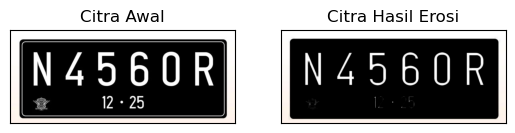

In [12]:
img = cv2.imread('../assets/plat-nomor.jpg')

if img is None:
    raise Exception('Image is not found!')

kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)

plt.subplot(121)
plt.imshow(img)
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(122)
plt.imshow(erosion)
plt.title('Citra Hasil Erosi')
plt.xticks([])
plt.yticks([])
plt.show()

## 5. Image Opening from Scratch

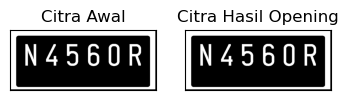

In [13]:
img = cv2.imread('../assets/plat-nomor.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

reto, thresh = cv2.threshold(
    img, 
    thresh=127, 
    maxval=225, 
    type=cv2.THRESH_BINARY
)

img_o = image_dilation(image_erosion(thresh, k=7), w=7)

plt.subplot(131)
plt.imshow(img_o,cmap = 'gray')
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(img_o,cmap = 'gray')
plt.title('Citra Hasil Opening')
plt.xticks([])
plt.yticks([])
plt.show()

## 6. Image Opening with OpenCV

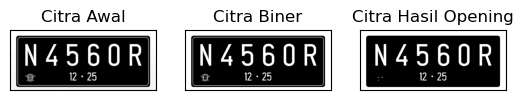

In [14]:
img = cv2.imread('../assets/plat-nomor.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img, 
    thresh=127, 
    maxval=225, 
    type=cv2.THRESH_BINARY
)

kernel = np.ones((3,3),np.uint8)
openn = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)

plt.subplot(131)
plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(thresh,cmap = 'gray')
plt.title('Citra Biner')
plt.xticks([])
plt.yticks([])
plt.subplot(133)
plt.imshow(openn,cmap = 'gray')
plt.title('Citra Hasil Opening')
plt.xticks([])
plt.yticks([])
plt.show()

## 7. Image Closing from Scratch

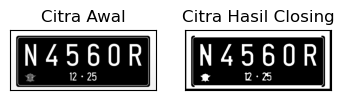

In [15]:
img = cv2.imread('../assets/plat-nomor.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

retc, thresh = cv2.threshold(
    img, 
    thresh=127, 
    maxval=225,
    type=cv2.THRESH_BINARY
)

img_c = image_erosion(image_dilation(thresh, w=7), k=7)

plt.subplot(131)
plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(img_c,cmap = 'gray')
plt.title('Citra Hasil Closing')
plt.xticks([])
plt.yticks([])
plt.show()

## 8. Image Closing with OpenCV

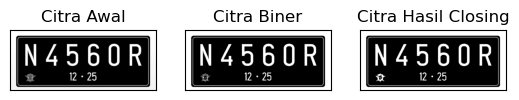

In [16]:
img = cv2.imread('../assets/plat-nomor.jpg', flags=cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception('Image is not found!')

ret, thresh = cv2.threshold(
    img, 
    thresh=127, 
    maxval=225, 
    type=cv2.THRESH_BINARY
)
kernel = np.ones((3,3),np.uint8)
closs = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE, kernel)

plt.subplot(131)
plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.imshow(thresh,cmap = 'gray')
plt.title('Citra Biner')
plt.xticks([])
plt.yticks([])
plt.subplot(133)
plt.imshow(closs,cmap = 'gray')
plt.title('Citra Hasil Closing')
plt.xticks([])
plt.yticks([])
plt.show()

## 9. Advanced Dilation

### 9.1 Cross (3x3) and (5x5)

### 9.2 Circular (3x3) and (5x5)

### 9.3 Rectangle (3x5) and (5x7)

### 9.4 Line vertical 3 and 5

## 10. Tophat

## 11. Blackhat

## 12. Skeleton

## 13. Skeleton Inverse

## 14. Thickening